In [85]:
import pandas as pd
import numpy as np1

In [86]:
#load the datsaset and undestand the data 
cs = pd.read_csv('customers.csv')
od = pd.read_csv('orders.csv')
od_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')   
   


In [87]:
cs.head(5)
cs.tail(5)

,customer_id,signup_date,state,acquisition_channel
3595,3596,2025-11-14,LA,referral
3596,3597,2025-05-27,WA,paid_search
3597,3598,2024-06-03,CA,paid_search
3598,3599,2025-08-23,LA,organic_search
3599,3600,2024-10-19,NY,organic_search


In [88]:
od.head(5)
od.tail(5)

,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
9240,109203,3499,2025-12-31 16:50:18,completed,credit_card,HOLIDAY20,6.95
9241,109204,3410,2025-12-31 17:40:58,completed,credit_card,HOLIDAY20,0.00
9242,109205,2911,2025-12-31 18:21:51,completed,credit_card,NaN,0.00
9243,109206,1157,2025-12-31 21:38:59,completed,credit_card,NaN,6.95
9244,109207,2208,2025-12-31 23:23:29,completed,paypal,HOLIDAY20,0.00


In [89]:
od_items.head(5)
od_items.tail(5)    

,order_id,product_id,quantity,unit_price,discount_amount
15603,109204,1070,1,129.14,25.83
15604,109205,1072,2,149.09,0.00
15605,109206,1071,1,10.49,0.00
15606,109207,1023,2,142.79,57.12
15607,109207,1043,1,134.39,26.88


In [90]:
products.head(5)  
products.tail(5)      

,product_id,product_name,category,list_price,unit_cost
85,1086,Modern Under Bed Bin,Storage,97.99,43.62
86,1087,Cotton Pantry Container Set,Storage,45.99,20.30
87,1088,Coastal Coat Rack,Storage,20.99,12.03
88,1089,Modern Floating Shelf,Storage,53.99,24.22
89,1090,Bamboo Laundry Basket,Storage,17.99,7.79


In [91]:
cs.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          3600 non-null   int64 
 1   signup_date          3600 non-null   object
 2   state                3600 non-null   object
 3   acquisition_channel  3600 non-null   object
dtypes: int64(1), object(3)
memory usage: 112.6+ KB


In [92]:
od.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9245 entries, 0 to 9244
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        9245 non-null   int64  
 1   customer_id     9245 non-null   int64  
 2   order_date      9245 non-null   object 
 3   status          9245 non-null   object 
 4   payment_method  9245 non-null   object 
 5   discount_code   1411 non-null   object 
 6   shipping_fee    9245 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 505.7+ KB


In [93]:
od_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15608 entries, 0 to 15607
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         15608 non-null  int64  
 1   product_id       15608 non-null  int64  
 2   quantity         15608 non-null  int64  
 3   unit_price       15409 non-null  float64
 4   discount_amount  15608 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 609.8 KB


In [94]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     int64  
 1   product_name  90 non-null     object 
 2   category      90 non-null     object 
 3   list_price    90 non-null     float64
 4   unit_cost     90 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 3.6+ KB


In [95]:
od_items.duplicated().sum()

np.int64(0)

In [96]:
# Check how many total duplicate rows exist in the dataframe
print("Total duplicate rows:", od_items.duplicated().sum())

# View rows where unit_price is missing
missing_prices = od_items[od_items['unit_price'].isnull()]
print(missing_prices.head())

Total duplicate rows: 0
     order_id  product_id  quantity  unit_price  discount_amount
55     100033        1086         1         NaN              0.0
110    100062        1020         1         NaN              0.0
197    100116        1087         2         NaN              0.0
366    100210        1014         1         NaN              0.0
626    100361        1077         1         NaN              0.0


In [97]:
# Beacause the unit_price is missing, we can use the product_id to look up the unit_cost from the products table and fill in the missing values.
# 1. Create a mapping dictionary or series from your product table
cost_mapping = products.set_index('product_id')['unit_cost']

# 2. Fill ONLY the missing values in 'unit_price' using product_id lookup
od_items['unit_price'] = od_items['unit_price'].fillna(od_items['product_id'].map(cost_mapping))

In [98]:
# Check how many duplicate rows exist in each table
print("Order items duplicates:", od_items.duplicated().sum())
print("Customers duplicates:", cs.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())
print("Order  duplicates:", od.duplicated().sum())


Order items duplicates: 0
Customers duplicates: 0
Products duplicates: 0
Order  duplicates: 38


In [99]:
# Remove duplicate rows from your orders table
orders = od.drop_duplicates()

# Verify they are gone
print("Remaining duplicates:", orders.duplicated().sum())

Remaining duplicates: 0


In [100]:
# Check unique values to spot casing differences, typos, or trailing spaces
print(orders['status'].unique())

['completed' 'returned' 'canceled']


In [ ]:
# Check data types to find text/object columns
print(products.dtypes)

product_id        int64
product_name     object
category         object
list_price      float64
unit_cost       float64
dtype: object


In [102]:
# Check all unique values in a text column to spot typos, spacing, or casing issues
print(products['category'].unique())

['Kitchen' ' Kitchen' 'Kitchen ' 'kitchen' 'KITCHEN' ' Bedding' 'Bedding'
 'bedding' 'BEDDING' 'Bath' 'bath' 'Furniture' 'Furniture ' 'furniture'
 'FURNITURE' 'Lighting' 'LIGHTING' 'Outdoor' 'OUTDOOR' ' Outdoor' 'Decor'
 'decor' 'Storage' 'Storage ']


In [103]:
# 1. Strip extra trailing/leading spaces and convert everything to lowercase
products['category'] = products['category'].str.strip().str.lower()

In [104]:
import pandas as pd

# 1. Calculate revenue for each item row
od_items['item_revenue'] = (od_items['quantity'] * od_items['unit_price']) - od_items['discount_amount']

# 2. Merge od_items with your orders table using 'order_id'
merged_df = od_items.merge(orders, on='order_id', how='inner')

# 3. Filter for successfully completed orders only
completed_orders = merged_df[merged_df['status'] == 'completed'].copy()

# 4. Convert order date to datetime and extract Year and Month
completed_orders['order_date'] = pd.to_datetime(completed_orders['order_date'])
completed_orders['year'] = completed_orders['order_date'].dt.year
completed_orders['month'] = completed_orders['order_date'].dt.month

# 5. Group by Year and Month, then sum the revenue
monthly_revenue = completed_orders.groupby(['year', 'month'])['item_revenue'].sum().reset_index()

# 6. Pivot the table so 2024 and 2025 are side-by-side for easy comparison
comparison_table = monthly_revenue.pivot(index='month', columns='year', values='item_revenue')

print(comparison_table)

year        2024       2025
month                      
1       54243.60   72639.13
2       63122.98   70084.90
3       71279.28   78157.01
4       64456.65   79511.29
5       73017.43   82416.53
6       66923.35   91492.85
7       76813.44   82837.38
8       62039.60   90296.09
9       60042.69   74902.91
10      67603.93   81797.48
11     100091.48  128450.11
12      86324.92   90954.47


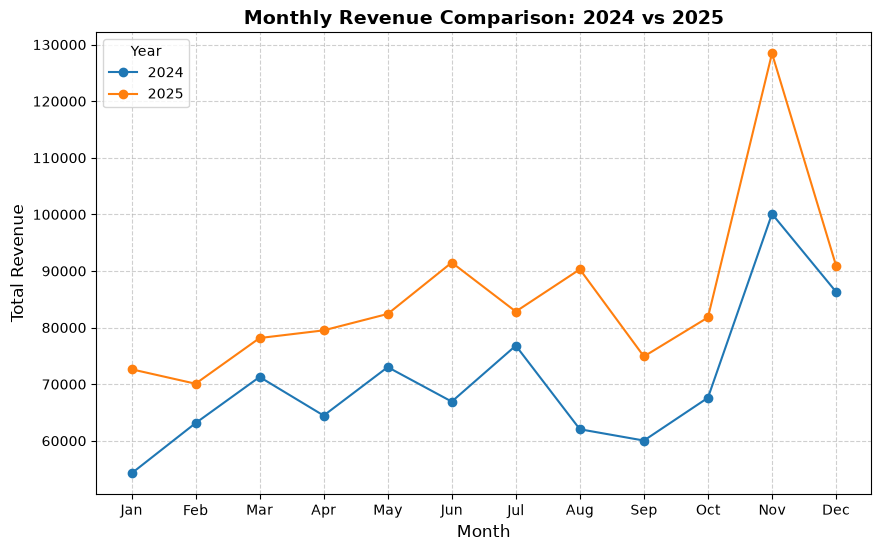

In [ ]:
import matplotlib.pyplot as plt

# Plotting the comparison table directly as a line chart
comparison_table.plot(kind='line', marker='o', figsize=(10, 6))


plt.title('Monthly Revenue Comparison: 2024 vs 2025', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Year')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Merge od_items with the products table 

item_product_df = od_items.merge(products, on='product_id', how='left')

# 2. Group by Category for your Pie Chart
category_revenue = item_product_df.groupby('category')['item_revenue'].sum().sort_values(ascending=False)

# 3. Group by Product Name for your Horizontal Bar Chart
top_products = item_product_df.groupby('product_name')['item_revenue'].sum().sort_values(ascending=True).tail(10)

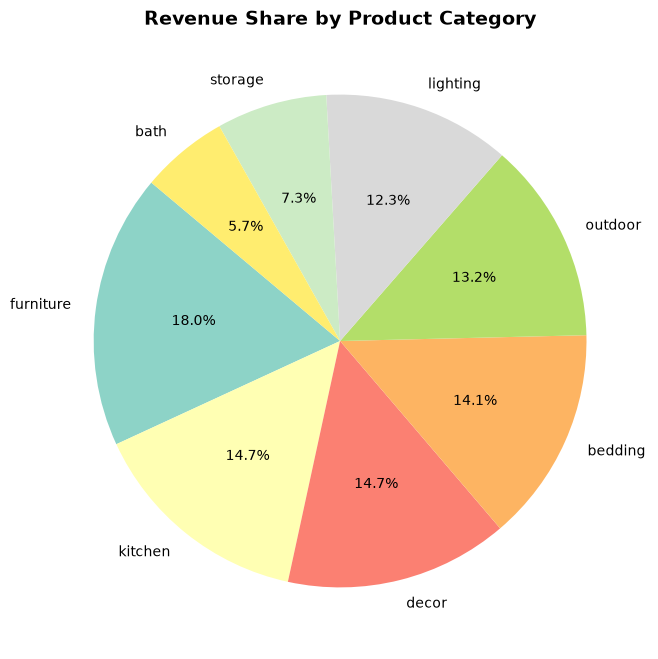

In [ ]:
# Create Pie Chart for Category Revenue Mix
plt.figure(figsize=(8, 8))
category_revenue.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='Set3')

plt.title('Revenue Share by Product Category', fontsize=14, fontweight='bold')
plt.ylabel('') 
plt.show()

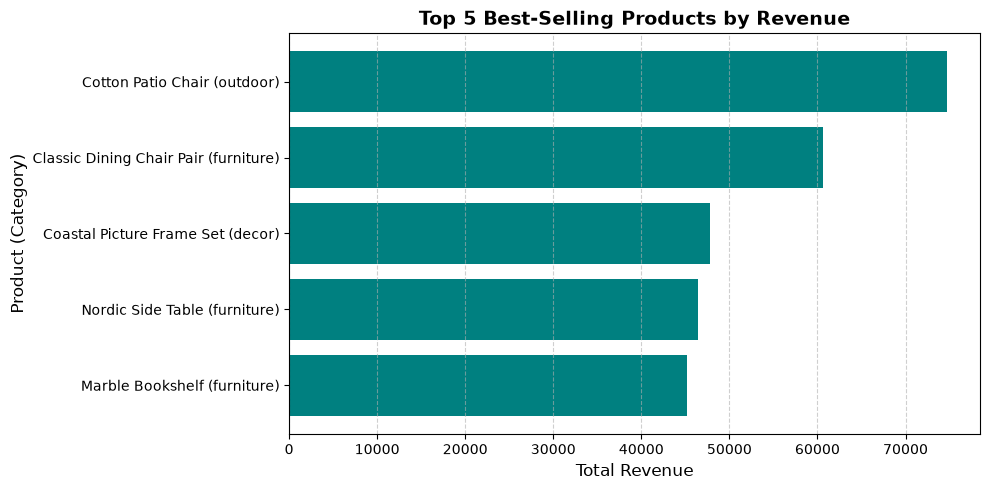

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by both Product Name and Category, then sum up the revenue
product_category_sales = item_product_df.groupby(['product_name', 'category'])['item_revenue'].sum().reset_index()

# Sort by revenue and get the top 5 best-sellers
top_5_products = product_category_sales.sort_values(by='item_revenue', ascending=True).tail(5)


top_5_products['label'] = top_5_products['product_name'] + ' (' + top_5_products['category'] + ')'

#  Plot the horizontal bar chart
plt.figure(figsize=(10, 5))
plt.barh(top_5_products['label'], top_5_products['item_revenue'], color='teal')

plt.title('Top 5 Best-Selling Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product (Category)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Merge your order items with the products table to get categories and product names
item_product_df = od_items.merge(products, on='product_id', how='left')

# erge with your orders table so you have the order date
item_product_df = item_product_df.merge(orders[['order_id', 'order_date', 'status']], on='order_id', how='left')

# filter for completed orders only (to stick to your revenue definition!)
item_product_df = item_product_df[item_product_df['status'] == 'completed']

category      bath    bedding      decor  furniture    kitchen   lighting  \
month                                                                       
1         6.133979  17.374642  14.265811  17.214888  16.992115  16.980514   
2         6.887858  17.136719  15.054522  19.130325  16.867748  11.561110   
3         5.902683  13.255321  12.955247  21.175519  15.100850  13.250737   
4         5.883525  13.238593  13.714178  16.877230  12.919015  11.020204   
5         5.435022  12.611420  11.661744  16.095929  12.361082  11.471573   
6         6.024138  12.071278  10.270982  10.426383  13.999717  11.472173   
7         4.756092  12.771929   9.621053  15.870272  13.049159  11.631309   
8         5.416275  12.523868  11.837837  14.901012  14.438192  13.184665   
9         5.744322  15.449314  14.298221  17.457724  13.491548  15.185956   
10        5.585750  13.991956  13.211596  19.778769  16.730304  15.683252   
11        6.558592  15.010397  21.567199  18.246373  15.897842  12.214280   

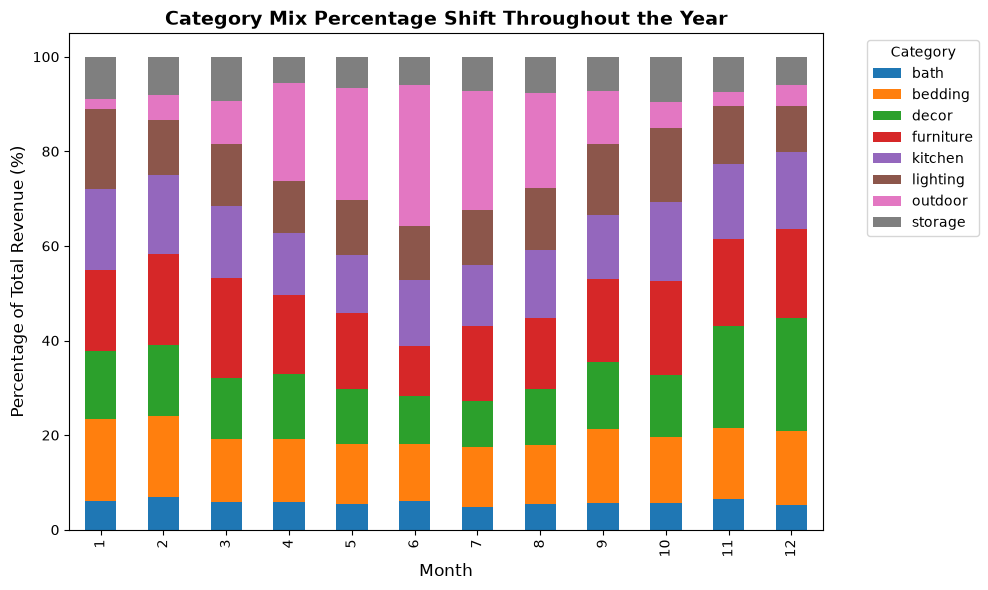

In [ ]:
# Calculate revenue for each item row
item_product_df['revenue'] = (item_product_df['quantity'] * item_product_df['unit_price']) - item_product_df['discount_amount']
item_product_df['order_date'] = pd.to_datetime(item_product_df['order_date'])
item_product_df['month'] = item_product_df['order_date'].dt.month

# 2. Group by month and category to get total revenue per category per month
monthly_category = item_product_df.groupby(['month', 'category'])['revenue'].sum().unstack(fill_value=0)

# 3. Convert those revenues into percentages 
monthly_category_pct = monthly_category.div(monthly_category.sum(axis=1), axis=0) * 100

print(monthly_category_pct)

monthly_category_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Category Mix Percentage Shift Throughout the Year', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage of Total Revenue (%)', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [111]:
import pandas as pd

# 1. Merge items, products, and orders to get category and status together
df_status = od_items.merge(products, on='product_id', how='left')
df_status = df_status.merge(orders[['order_id', 'status']], on='order_id', how='left')

# 2. Create a column to flag if an order was canceled or returned
df_status['is_cancelled_or_returned'] = df_status['status'].isin(['canceled', 'returned'])

# 3. Group by category to find the cancellation/return rate percentage
category_issues = df_status.groupby('category')['is_cancelled_or_returned'].mean() * 100
print("--- Return/Cancellation Rate by Category (%) ---")
print(category_issues.sort_values(ascending=False))

--- Return/Cancellation Rate by Category (%) ---
category
furniture    14.736842
bath          8.735632
outdoor       8.468835
bedding       8.281573
decor         8.200456
kitchen       8.075117
storage       7.397408
lighting      6.718147
Name: is_cancelled_or_returned, dtype: float64


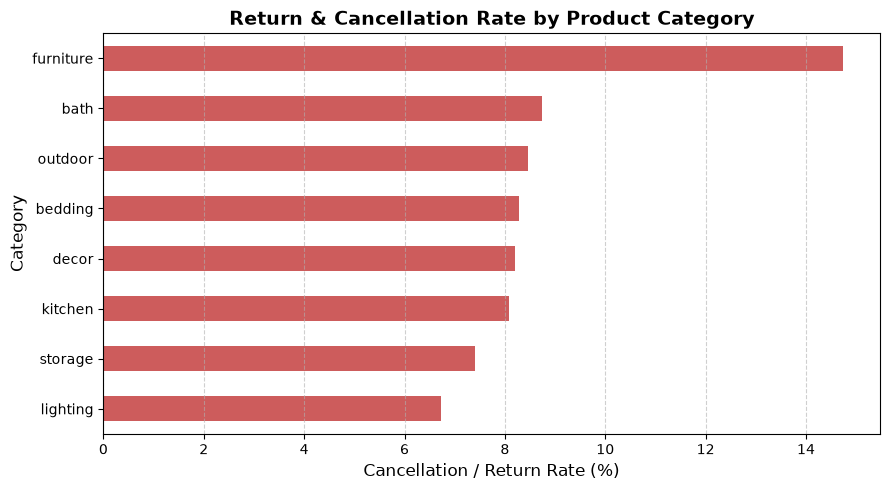

In [112]:
import matplotlib.pyplot as plt

# Sort the values from lowest to highest so the highest return rate appears at the top
category_issues_sorted = category_issues.sort_values(ascending=True)

plt.figure(figsize=(9, 5))
category_issues_sorted.plot(kind='barh', color='indianred')

plt.title('Return & Cancellation Rate by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Cancellation / Return Rate (%)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [113]:
# 1. Calculate line item revenue for successful orders
completed_df = df_status[df_status['status'] == 'completed'].copy()
completed_df['revenue'] = (completed_df['quantity'] * completed_df['unit_price']) - completed_df['discount_amount']

# 2. Group by category to find Average Order Value (AOV)
category_aov = completed_df.groupby('category')['revenue'].mean()
print("\n--- Average Order Value (AOV) by Category ---")
print(category_aov.sort_values(ascending=False))


--- Average Order Value (AOV) by Category ---
category
furniture    360.046229
lighting     195.513924
outdoor      181.923227
bedding      149.878600
decor         97.798497
kitchen       94.656095
storage       80.875697
bath          68.361461
Name: revenue, dtype: float64


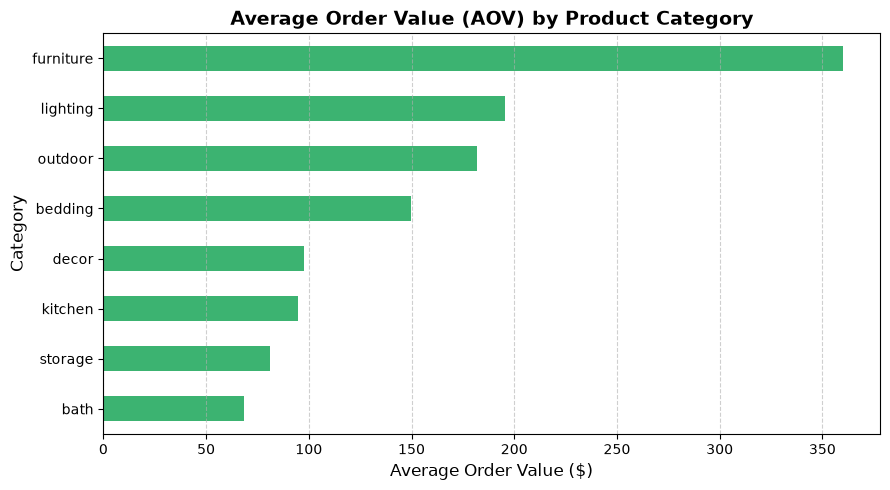

In [114]:
# Sort the values from lowest to highest so the highest AOV appears at the top
category_aov_sorted = category_aov.sort_values(ascending=True)

plt.figure(figsize=(9, 5))
category_aov_sorted.plot(kind='barh', color='mediumseagreen')

plt.title('Average Order Value (AOV) by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Order Value ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()